In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# These libraries provide numerical operations, tabular data handling, and plotting support.


In [66]:
# -----------------------------------------------------------------------------
# 1. LOAD DATA
# -----------------------------------------------------------------------------
# Load the cleaned options-chain dataset from disk.
nifty50_data = pd.read_parquet(r'C:\Users\Admin\Downloads\nifty_options_chain_clean_2023-01-02_to_2026-05-15.parquet', engine='fastparquet')
nifty50_data.head()

,ticker,bar_minute,open,high,low,close,volume,expiry,opt_type,strike,feed_era,is_closing_bar
0,NIFTY230105P15050,2023-01-02 09:15:00,0.60,0.60,0.50,0.50,3750,2023-01-05,P,15050.0,vendor59,False
1,NIFTY230105P15100,2023-01-02 09:15:00,0.50,0.55,0.40,0.40,3050,2023-01-05,P,15100.0,vendor59,False
2,NIFTY230105P15150,2023-01-02 09:15:00,0.60,0.60,0.55,0.55,1750,2023-01-05,P,15150.0,vendor59,False
3,NIFTY230105P15200,2023-01-02 09:15:00,0.65,0.65,0.60,0.60,450,2023-01-05,P,15200.0,vendor59,False
4,NIFTY230105P15250,2023-01-02 09:15:00,0.60,0.60,0.60,0.60,100,2023-01-05,P,15250.0,vendor59,False


In [67]:
# -----------------------------------------------------------------------------
# 2. FILTER TO THE LAST 12 MONTHS
# -----------------------------------------------------------------------------
# Keep only rows whose expiry falls within the target one-year window.
nifty50_1yr_data = nifty50_data[(nifty50_data['expiry'] >= '2025-06-30') & (nifty50_data['expiry'] <= '2026-06-30')]
nifty50_1yr_data.isnull().sum()

ticker            0
bar_minute        0
open              0
high              0
low               0
close             0
volume            0
expiry            0
opt_type          0
strike            0
feed_era          0
is_closing_bar    0
dtype: int64

In [68]:
# -----------------------------------------------------------------------------
# 3. EXPLORE THE FILTERED DATA
# -----------------------------------------------------------------------------
# Summarize the filtered options data to confirm the time range and coverage.
print('Rows:', len(nifty50_1yr_data))
print('Data types:')
print(nifty50_1yr_data[['bar_minute', 'expiry', 'strike', 'opt_type']].dtypes)
print('Date range:', nifty50_1yr_data['bar_minute'].min(), 'to', nifty50_1yr_data['bar_minute'].max())
print('Unique expiries:', nifty50_1yr_data['expiry'].nunique())
print('Unique strikes:', nifty50_1yr_data['strike'].nunique())
print('Option types:', nifty50_1yr_data['opt_type'].unique())

# Determine the last 12-month window from the latest timestamp.
last_bar = nifty50_1yr_data['bar_minute'].max()
start_last_year = last_bar - pd.Timedelta(days=365)
print('Last-one-year window:', start_last_year, 'to', last_bar)
print('Rows in last one year:', len(nifty50_1yr_data[nifty50_1yr_data['bar_minute'] >= start_last_year]))

# Count unique trading dates in the selected window.
unique_dates = nifty50_1yr_data[nifty50_1yr_data['bar_minute'] >= start_last_year]['bar_minute'].dt.date.nunique()
print('Unique trading dates last one year:', unique_dates)

# Estimate the spot price from synthetic call/put parity when both sides are present.
pairs = nifty50_1yr_data.pivot_table(
    index=['bar_minute', 'expiry', 'strike'],
    columns='opt_type',
    values='close',
    aggfunc='first'
).dropna()

if 'C' in pairs.columns and 'P' in pairs.columns:
    pairs = pairs.reset_index()
    pairs['synthetic_spot'] = pairs['strike'] + (pairs['C'] - pairs['P'])
    print('Sample synthetic spot:', pairs['synthetic_spot'].head(3).tolist())
    print('Synthetic spot range:', pairs['synthetic_spot'].min(), pairs['synthetic_spot'].max())
    print('Paired rows used for spot estimate:', len(pairs))
else:
    print('Not enough paired C/P data to compute spot estimate.')

Rows: 16198070
Data types:
bar_minute    datetime64[us]
expiry        datetime64[ns]
strike               float64
opt_type              object
dtype: object
Date range: 2023-01-02 09:36:00 to 2026-05-15 15:30:00
Unique expiries: 45
Unique strikes: 179
Option types: ['C' 'P']
Last-one-year window: 2025-05-15 15:30:00 to 2026-05-15 15:30:00
Rows in last one year: 15723444
Unique trading dates last one year: 135
Sample synthetic spot: [22060.0, 24213.05, 24200.0]
Synthetic spot range: 22055.4 28081.0
Paired rows used for spot estimate: 3714064


In [69]:
# -----------------------------------------------------------------------------
# 4. BUILD THE SYNTHETIC SPOT SERIES
# -----------------------------------------------------------------------------
# Create a one-year intraday dataset and derive a synthetic spot using front-month call/put parity.
full_data = nifty50_1yr_data.copy()
full_data['bar_minute'] = pd.to_datetime(full_data['bar_minute'])
full_data['expiry'] = pd.to_datetime(full_data['expiry'])

last_bar = full_data['bar_minute'].max()
start_last_year = last_bar - pd.Timedelta(days=365)
data_365 = full_data[full_data['bar_minute'] >= start_last_year].copy()
print('Selected data range:', start_last_year, 'to', last_bar)
print('Rows in one-year dataset:', len(data_365))

# Use the front-month expiry at each timestamp for signal generation.
front_expiry = data_365.groupby('bar_minute')['expiry'].min().reset_index()
front_data = data_365.merge(front_expiry, on=['bar_minute', 'expiry'], how='inner')
print('Rows after front-month selection:', len(front_data))

# Pivot the front-month data so call and put prices are aligned by strike.
front_pivot = front_data.pivot_table(
    index=['bar_minute', 'strike'],
    columns='opt_type',
    values='close',
    aggfunc='first'
).dropna().reset_index()

front_pivot['synthetic_spot'] = front_pivot['strike'] + (front_pivot['C'] - front_pivot['P'])
front_pivot['atm_dist'] = (front_pivot['strike'] - front_pivot['synthetic_spot']).abs()

# Pick the ATM strike for each timestamp to build the spot proxy.
atm_df = front_pivot.loc[front_pivot.groupby('bar_minute')['atm_dist'].idxmin()].copy()
atm_df = atm_df.rename(columns={'C': 'call_price', 'P': 'put_price'})
atm_df = atm_df.sort_values('bar_minute').reset_index(drop=True)
atm_df['spot'] = atm_df['synthetic_spot']

# Create OTM legs for the semi-directional strategy using the nearest strike step.
strike_steps = np.unique(np.diff(np.sort(atm_df['strike'].unique())))
strike_step = int(np.nanmin(strike_steps)) if len(strike_steps) else 100
otm_call = front_pivot[['bar_minute', 'strike', 'C']].rename(columns={'strike': 'strike_otm', 'C': 'otm_call_price'})
otm_put = front_pivot[['bar_minute', 'strike', 'P']].rename(columns={'strike': 'strike_otm', 'P': 'otm_put_price'})

atm_df['strike_otm_call'] = atm_df['strike'] + strike_step
atm_df['strike_otm_put'] = atm_df['strike'] - strike_step

atm_df = atm_df.merge(
    otm_call,
    left_on=['bar_minute', 'strike_otm_call'],
    right_on=['bar_minute', 'strike_otm'],
    how='left'
).drop(columns=['strike_otm'])

atm_df = atm_df.merge(
    otm_put,
    left_on=['bar_minute', 'strike_otm_put'],
    right_on=['bar_minute', 'strike_otm'],
    how='left'
).drop(columns=['strike_otm'])

atm_df = atm_df.sort_values('bar_minute').reset_index(drop=True)
print('ATM instrument count:', len(atm_df))
print('Sample front-month spot data:')
print(atm_df.head())

Selected data range: 2025-05-15 15:30:00 to 2026-05-15 15:30:00
Rows in one-year dataset: 15723444
Rows after front-month selection: 4984541
ATM instrument count: 46938
Sample front-month spot data:
opt_type          bar_minute   strike  call_price  put_price  synthetic_spot  \
0        2025-05-16 09:15:00  25500.0      548.15     706.20        25341.95   
1        2025-05-16 09:16:00  25500.0      570.00     700.75        25369.25   
2        2025-05-16 09:17:00  25500.0      566.85     713.20        25353.65   
3        2025-05-16 09:18:00  25500.0      564.65     703.50        25361.15   
4        2025-05-16 09:19:00  25500.0      555.65     710.00        25345.65   

opt_type  atm_dist      spot  strike_otm_call  strike_otm_put  otm_call_price  \
0           158.05  25341.95          25550.0         25450.0             NaN   
1           130.75  25369.25          25550.0         25450.0             NaN   
2           146.35  25353.65          25550.0         25450.0             NaN

In [70]:
# -----------------------------------------------------------------------------
# 5. PREPARE FEATURE VARIABLES FOR SIGNALS
# -----------------------------------------------------------------------------
# Create daily-date labels and build volatility-based technical features.
session_data = atm_df.copy()
session_data['date'] = session_data['bar_minute'].dt.date
session_data = session_data.sort_values(['date', 'bar_minute']).reset_index(drop=True)

# True Range and ATR for volatility scaling.
session_data['tr'] = session_data['spot'].diff().abs()
session_data['atr'] = session_data['tr'].rolling(14, min_periods=5).mean()
session_data['atr_norm'] = session_data['atr'] / session_data['spot']

# Adaptive EMA alpha derived from expanding ATR normalization.
session_data['atr_norm_min'] = session_data['atr_norm'].expanding().min()
session_data['atr_norm_max'] = session_data['atr_norm'].expanding().max()
session_data['aema_alpha'] = (session_data['atr_norm'] - session_data['atr_norm_min']) / (
    session_data['atr_norm_max'] - session_data['atr_norm_min'] + 1e-8
)

# Adaptive EMA (AEMA) with no look-ahead bias.
session_data['aema'] = np.nan
prev = np.nan
for idx, (spot, alpha) in enumerate(zip(session_data['spot'], session_data['aema_alpha'])):
    if idx == 0 or np.isnan(spot) or np.isnan(alpha):
        prev = spot
        session_data.at[idx, 'aema'] = spot
    else:
        prev = alpha * spot + (1 - alpha) * prev
        session_data.at[idx, 'aema'] = prev

# Z-score and trend strength feature columns.
session_data['zscore'] = (session_data['spot'] - session_data['aema']) / session_data['aema'].std()
session_data['trend'] = session_data['spot'] - session_data['aema']
session_data['trend_strength'] = session_data['trend'].abs() / session_data['atr']

# Optional half-life feature for exploration; it is not used by the final strategy.
def ou_half_life(series):
    lag = series.shift(1)
    delta = series - lag
    valid = lag.notna() & delta.notna()
    if valid.sum() < 15:
        return np.nan
    beta = np.polyfit(lag[valid], delta[valid], 1)[0]
    return -np.log(2) / beta if beta < 0 else np.nan

session_data['half_life'] = session_data['spot'].rolling(60, min_periods=20).apply(ou_half_life, raw=False)

In [71]:
# -----------------------------------------------------------------------------
# 6. CONVERT TO DAILY SIGNAL DATA
# -----------------------------------------------------------------------------
# Aggregate intraday spot values to daily open/high/low/close values and create strategy signals.
session_data = session_data.sort_values(['date', 'bar_minute']).reset_index(drop=True)

daily_df = session_data.groupby('date').agg(
    spot_open=('spot', 'first'),
    spot_high=('spot', 'max'),
    spot_low=('spot', 'min'),
    spot_close=('spot', 'last'),
    aema_open=('aema', 'first'),
    aema_close=('aema', 'last'),
    atr_open=('atr', 'first'),
    atr_close=('atr', 'last')
).reset_index()

daily_df = daily_df.sort_values('date').reset_index(drop=True)
daily_df = daily_df.loc[daily_df['spot_open'] > 0].copy()

# Create lagged price features so signals depend only on past information.
daily_df['prev_close'] = daily_df['spot_close'].shift(1)
daily_df['prev_high'] = daily_df['spot_high'].shift(1)
daily_df['prev_low'] = daily_df['spot_low'].shift(1)

daily_df['mr_mean'] = daily_df['prev_close'].rolling(20, min_periods=10).mean()
daily_df['mr_std'] = daily_df['prev_close'].rolling(20, min_periods=10).std().replace(0, np.nan)
daily_df['mr_zscore'] = (daily_df['spot_open'] - daily_df['mr_mean']) / daily_df['mr_std']

daily_df['trend_fast'] = daily_df['prev_close'].ewm(span=5, adjust=False).mean()
daily_df['trend_slow'] = daily_df['prev_close'].ewm(span=20, adjust=False).mean()
daily_df['trend_gap'] = daily_df['trend_fast'] - daily_df['trend_slow']
daily_df['trend_momentum'] = daily_df['trend_gap'] / daily_df['trend_slow'].replace(0, np.nan)
daily_df['trend_strength'] = daily_df['trend_gap'].abs() / daily_df['atr_open'].replace(0, np.nan)
daily_df['breakout_strength'] = (daily_df['spot_open'] - daily_df['prev_close']).abs() / daily_df['atr_open'].replace(0, np.nan)

# Mean-reversion signal.
daily_df['mean_signal'] = 0
daily_df.loc[daily_df['mr_zscore'] < -1.0, 'mean_signal'] = 1
daily_df.loc[daily_df['mr_zscore'] > 1.0, 'mean_signal'] = -1

# Trend-following signal with breakout confirmation.
daily_df['trend_signal'] = 0
momentum_threshold = 0.0015
strength_threshold = 0.35
breakout_threshold = 0.2

daily_df.loc[
    (daily_df['spot_open'] > daily_df['prev_close']) &
    (daily_df['trend_gap'] > 0) &
    (daily_df['trend_momentum'] > momentum_threshold) &
    (daily_df['trend_strength'] > strength_threshold) &
    (daily_df['breakout_strength'] > breakout_threshold),
    'trend_signal'
] = 1

daily_df.loc[
    (daily_df['spot_open'] < daily_df['prev_close']) &
    (daily_df['trend_gap'] < 0) &
    (daily_df['trend_momentum'] < -momentum_threshold) &
    (daily_df['trend_strength'] > strength_threshold) &
    (daily_df['breakout_strength'] > breakout_threshold),
    'trend_signal'
] = -1

# Semi-directional breakout signal.
daily_df['semi_signal'] = 0
daily_df.loc[daily_df['spot_open'] > daily_df['prev_high'], 'semi_signal'] = 1
daily_df.loc[daily_df['spot_open'] < daily_df['prev_low'], 'semi_signal'] = -1

# Convert each signal into a daily percentage return.
for label, signal_col in [('mean', 'mean_signal'), ('trend', 'trend_signal'), ('semi', 'semi_signal')]:
    daily_df[f'{label}_pnl'] = np.where(
        daily_df[signal_col] == 1,
        (daily_df['spot_close'] - daily_df['spot_open']) / daily_df['spot_open'],
        np.where(daily_df[signal_col] == -1, (daily_df['spot_open'] - daily_df['spot_close']) / daily_df['spot_open'], 0.0)
    )

print(daily_df[['date', 'spot_open', 'spot_close', 'mr_zscore', 'mean_signal', 'mean_pnl', 'trend_signal', 'trend_pnl', 'semi_signal', 'semi_pnl']].head())

         date  spot_open  spot_close  mr_zscore  mean_signal  mean_pnl  \
0  2025-05-16   25341.95    25336.40        NaN            0       0.0   
1  2025-05-19   25274.30    25223.40        NaN            0       0.0   
2  2025-05-20   25265.75    25034.05        NaN            0       0.0   
3  2025-05-21   25039.10    25074.80        NaN            0       0.0   
4  2025-05-22   25006.45    24918.25        NaN            0       0.0   

   trend_signal  trend_pnl  semi_signal  semi_pnl  
0             0   0.000000            0       0.0  
1             0   0.000000            0       0.0  
2             0   0.000000            0       0.0  
3             0   0.000000            0       0.0  
4            -1   0.003527            0       0.0  


In [72]:
# -----------------------------------------------------------------------------
# 7. INSPECT TRADE COUNTS FOR EACH STRATEGY
# -----------------------------------------------------------------------------
# Summarize how often each strategy produces a non-zero signal.
mean_df = daily_df[['date', 'spot_open', 'spot_close', 'mr_zscore']].copy()
mean_df['mean_rev_pnl'] = daily_df['mean_pnl']
mean_df['mean_rev_trade'] = mean_df['mean_rev_pnl'] != 0
print(f"Mean reversion trades: {mean_df['mean_rev_trade'].sum()}")

trend_df = daily_df[['date', 'spot_open', 'spot_close', 'trend_fast', 'trend_slow', 'trend_momentum']].copy()
trend_df['trend_pnl'] = daily_df['trend_pnl']
trend_df['trend_trade'] = trend_df['trend_pnl'] != 0
print(f"Trend trades: {trend_df['trend_trade'].sum()}")

semi_df = daily_df[['date', 'spot_open', 'spot_close', 'prev_high', 'prev_low']].copy()
semi_df['semi_pnl'] = daily_df['semi_pnl']
semi_df['semi_trade'] = semi_df['semi_pnl'] != 0
print(f"Semi-directional trades: {semi_df['semi_trade'].sum()}")


Mean reversion trades: 65
Trend trades: 55
Semi-directional trades: 50


In [73]:
# -----------------------------------------------------------------------------
# 8. BUILD THE PORTFOLIO AND EQUITY CURVES
# -----------------------------------------------------------------------------
# Combine strategy returns into a blended portfolio and track the equity curve.
portfolio_df = pd.DataFrame({
    'date': daily_df['date'],
    'mean_rev_pnl': daily_df['mean_pnl'],
    'trend_pnl': daily_df['trend_pnl'],
    'semi_pnl': daily_df['semi_pnl']
})

# Estimate rolling volatility for each strategy to create inverse-volatility weights.
window = 20
portfolio_df['vol_mean'] = portfolio_df['mean_rev_pnl'].rolling(window, min_periods=10).std().fillna(0)
portfolio_df['vol_trend'] = portfolio_df['trend_pnl'].rolling(window, min_periods=10).std().fillna(0)
portfolio_df['vol_semi'] = portfolio_df['semi_pnl'].rolling(window, min_periods=10).std().fillna(0)

eps = 1e-8
portfolio_df['w_mean'] = 1 / (portfolio_df['vol_mean'] + eps)
portfolio_df['w_trend'] = 1 / (portfolio_df['vol_trend'] + eps)
portfolio_df['w_semi'] = 1 / (portfolio_df['vol_semi'] + eps)

total = portfolio_df[['w_mean', 'w_trend', 'w_semi']].sum(axis=1)
for col in ['w_mean', 'w_trend', 'w_semi']:
    portfolio_df[col] = portfolio_df[col] / total.replace(0, np.nan)
portfolio_df[['w_mean', 'w_trend', 'w_semi']] = portfolio_df[['w_mean', 'w_trend', 'w_semi']].fillna(1/3)

# Blend the strategies with a more stable ensemble weighting.
portfolio_df['ensemble_pnl'] = (
    0.45 * portfolio_df['mean_rev_pnl'] +
    0.15 * portfolio_df['trend_pnl'] +
    0.40 * portfolio_df['semi_pnl']
)

initial_capital = 100.0
portfolio_df['mean_equity'] = initial_capital * (1 + portfolio_df['mean_rev_pnl']).cumprod()
portfolio_df['trend_equity'] = initial_capital * (1 + portfolio_df['trend_pnl']).cumprod()
portfolio_df['semi_equity'] = initial_capital * (1 + portfolio_df['semi_pnl']).cumprod()
portfolio_df['ensemble_equity'] = initial_capital * (1 + portfolio_df['ensemble_pnl']).cumprod()

print("Portfolio construction complete.")

Portfolio construction complete.


In [75]:
# -----------------------------------------------------------------------------
# 9. CALCULATE PERFORMANCE METRICS
# -----------------------------------------------------------------------------
# Compute risk-adjusted metrics for each strategy from the equity curve.
results_df = portfolio_df.copy()

for label in ['mean', 'trend', 'semi', 'ensemble']:
    eq_col = f'{label}_equity'
    results_df[f'{label}_ret'] = results_df[eq_col].pct_change().fillna(0)

pnl_map = {
    'mean': 'mean_rev_pnl',
    'trend': 'trend_pnl',
    'semi': 'semi_pnl',
    'ensemble': 'ensemble_pnl'
}

metrics = {}
for label in ['mean', 'trend', 'semi', 'ensemble']:
    ret = results_df[f'{label}_ret']
    eq = results_df[f'{label}_equity']
    pnl = results_df[pnl_map[label]]
    trades = pnl[pnl != 0].dropna()
    win_rate = (trades > 0).mean() if len(trades) > 0 else np.nan

    valid_ret = ret.replace([np.inf, -np.inf], np.nan).dropna()
    cagr = np.nan
    if len(valid_ret) > 1:
        cumulative_growth = np.prod(1 + valid_ret)
        cagr = cumulative_growth ** (252 / len(valid_ret)) - 1

    sharpe = np.nan
    if valid_ret.std() != 0:
        sharpe = valid_ret.mean() / valid_ret.std() * np.sqrt(252)

    cummax = eq.cummax()
    drawdown = (cummax - eq) / cummax.replace(0, np.nan)
    mdd = drawdown.max() if drawdown.notna().any() else np.nan

    calmar = np.nan
    if pd.notna(mdd) and mdd > 0 and np.isfinite(cagr):
        calmar = cagr / mdd

    metrics[label] = {
        'Total PnL': eq.iloc[-1] - initial_capital,
        'CAGR': cagr,
        'Sharpe': sharpe,
        'Max DD': mdd,
        'Win Rate': win_rate,
        'Avg Trade PnL': trades.mean() if len(trades) > 0 else np.nan,
        'Num Trades': len(trades),
        'Final Equity': eq.iloc[-1],
        'Calmar': calmar
    }

metrics_df = pd.DataFrame(metrics).T
print("\n=== Strategy Performance Metrics ===")
print(metrics_df.round(4))


=== Strategy Performance Metrics ===
          Total PnL    CAGR  Sharpe  Max DD  Win Rate  Avg Trade PnL  \
mean         1.0817  0.0204  0.3346  0.0354    0.4923         0.0002   
trend        0.3919  0.0074  0.1513  0.0383    0.6000         0.0001   
semi         3.9324  0.0752  1.2035  0.0383    0.6000         0.0008   
ensemble     2.1952  0.0417  1.4048  0.0172    0.5701         0.0002   

          Num Trades  Final Equity  Calmar  
mean            65.0      101.0817  0.5779  
trend           55.0      100.3919  0.1927  
semi            50.0      103.9324  1.9636  
ensemble       107.0      102.1952  2.4194  


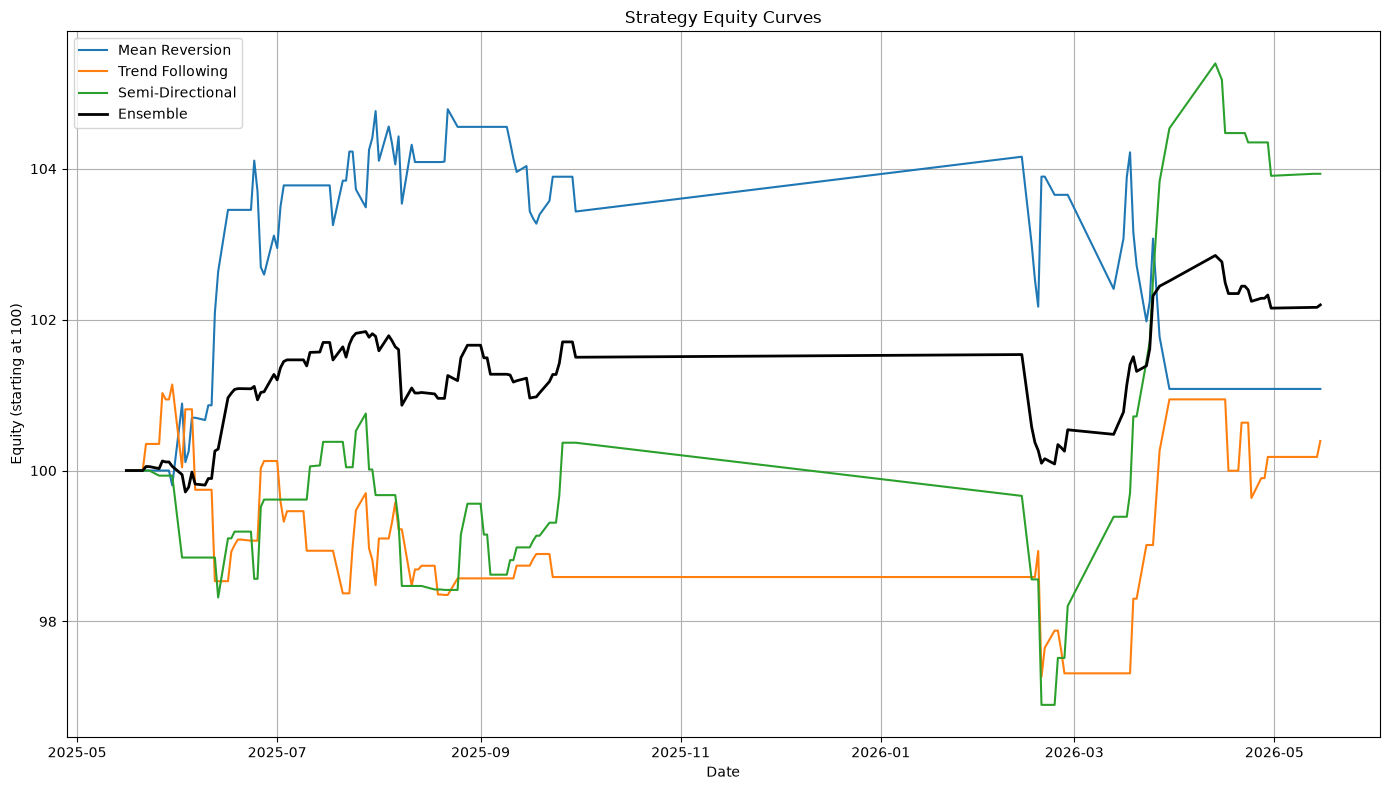


Saved strategy_metrics_summary.csv and strategy_returns_log.csv
================================== Backtest Complete ==================================


In [76]:
# -----------------------------------------------------------------------------
# 10. SAVE OUTPUTS AND PLOT RESULTS
# -----------------------------------------------------------------------------
# Save the metrics table and the daily return log for downstream analysis.
metrics_df.to_csv('strategy_metrics_summary.csv')
results_df.to_csv('strategy_returns_log.csv', index=False)

plt.figure(figsize=(14, 8))
plt.plot(results_df['date'], results_df['mean_equity'], label='Mean Reversion')
plt.plot(results_df['date'], results_df['trend_equity'], label='Trend Following')
plt.plot(results_df['date'], results_df['semi_equity'], label='Semi-Directional')
plt.plot(results_df['date'], results_df['ensemble_equity'], label='Ensemble', linewidth=2, color='black')
plt.title('Strategy Equity Curves')
plt.xlabel('Date')
plt.ylabel('Equity (starting at 100)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nSaved strategy_metrics_summary.csv and strategy_returns_log.csv")
print("================================== Backtest Complete ==================================")